# MetTraff: Targeted Feature Expansion of Meteorological Data for Dynamic Traffic Flow Prediction and Optimization

**Final Project — Machine Learning Course**

This notebook covers:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering (meteorological + temporal features)
- **Regression models**: Linear Regression, Decision Tree, Random Forest, XGBoost, CatBoost
- **Classification models**: Logistic Regression, Decision Tree, Random Forest, XGBoost
- **Clustering**: K-Means
- **Evaluation metrics**: MAE, RMSE, R² (regression) and Accuracy, Precision, Recall, F1-score (classification), Silhouette Score (clustering)
- **3 Test Scenarios**: Method comparison, Feature ablation, Hyperparameter tuning

# 1. Imports & Data Upload

In [4]:
!pip install catboost xgboost optuna -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score
)
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor
import optuna

sns.set(style='whitegrid')
np.random.seed(42)

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume (1).csv


In [7]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
print('Shape:', df.shape)
df.head()

Shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


# 2. Data Cleaning

Steps:
1. Inspect missing values and data types
2. Handle missing values in `holiday` column
3. Remove duplicate rows
4. Detect outliers using IQR method
5. Remove extreme/erroneous values (impossible temperatures, extreme rain)

In [8]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [9]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [10]:
# Handle missing values in 'holiday' column
df['holiday'] = df['holiday'].fillna('None')
print('Missing after fill:', df['holiday'].isnull().sum())

Missing after fill: 0


In [11]:
# Remove duplicates
print('Duplicates before:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Shape after dedup:', df.shape)

Duplicates before: 17
Shape after dedup: (48187, 9)


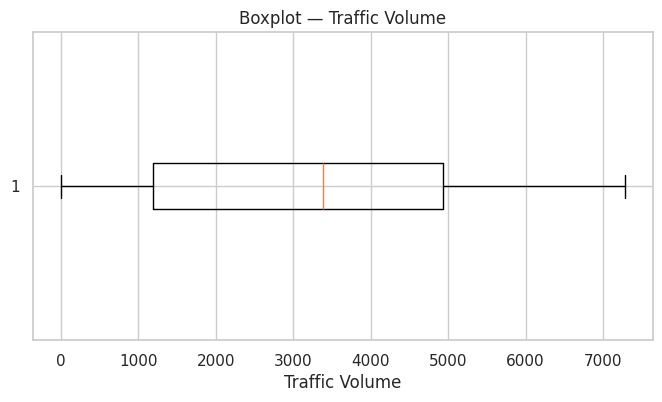

In [12]:
# Boxplot to inspect traffic_volume distribution
plt.figure(figsize=(8,4))
plt.boxplot(df['traffic_volume'], vert=False)
plt.title('Boxplot — Traffic Volume')
plt.xlabel('Traffic Volume')
plt.show()

In [13]:
# IQR-based outlier detection for numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print('IQR outlier counts:')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'  {col}: {len(outliers)} outliers')

IQR outlier counts:
  temp: 10 outliers
  rain_1h: 3467 outliers
  snow_1h: 63 outliers
  clouds_all: 0 outliers
  traffic_volume: 0 outliers


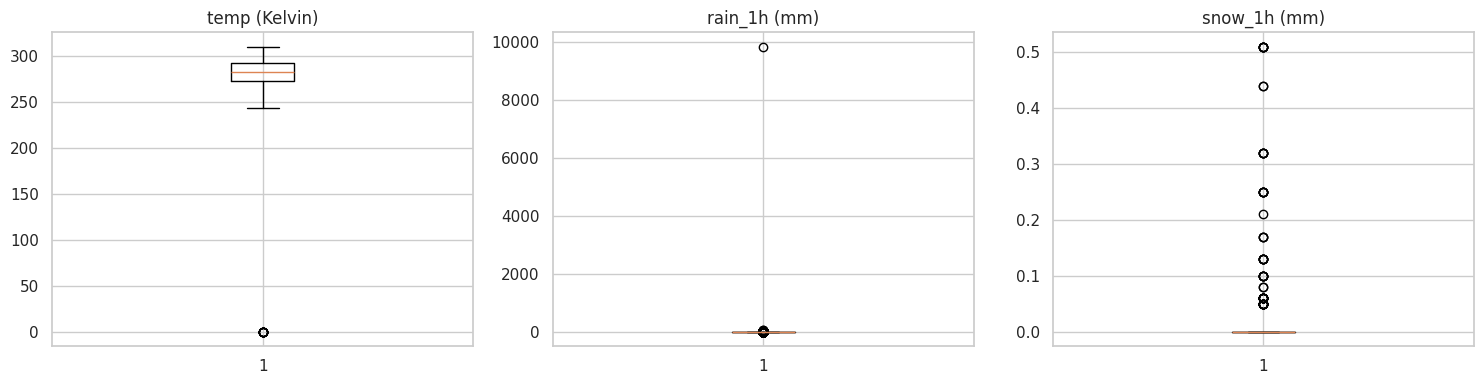

In [14]:
# Inspect temperature and rain — they have known data errors (0 Kelvin temps, 9000mm rain)
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].boxplot(df['temp']); axes[0].set_title('temp (Kelvin)')
axes[1].boxplot(df['rain_1h']); axes[1].set_title('rain_1h (mm)')
axes[2].boxplot(df['snow_1h']); axes[2].set_title('snow_1h (mm)')
plt.tight_layout()
plt.show()

In [15]:
# Remove impossible values: temp = 0 K, rain = 9831 mm (data entry errors)
df_clean = df.copy()
df_clean = df_clean[df_clean['temp'] > 200]      # remove 0-Kelvin readings
df_clean = df_clean[df_clean['rain_1h'] < 1000]  # remove 9831 mm rain outlier

print('Shape after cleaning:', df_clean.shape)
print('Temp range :', df_clean['temp'].min(), '-', df_clean['temp'].max())
print('Rain max   :', df_clean['rain_1h'].max())

Shape after cleaning: (48176, 9)
Temp range : 243.39 - 310.07
Rain max   : 55.63


In [16]:
df_clean.to_csv('traffic_clean.csv', index=False)
print('Cleaned dataset saved.')

Cleaned dataset saved.


# 3. Exploratory Data Analysis (EDA)

In [17]:
# Extract temporal features for EDA
df_clean['date_time'] = pd.to_datetime(df_clean['date_time'])
df_clean['hour'] = df_clean['date_time'].dt.hour
df_clean['dayofweek'] = df_clean['date_time'].dt.dayofweek
df_clean['month'] = df_clean['date_time'].dt.month
df_clean['is_weekend'] = (df_clean['dayofweek'] >= 5).astype(int)
df_clean['is_rush_hour'] = df_clean['hour'].apply(
    lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 18) else 0
)
df_clean.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,dayofweek,month,is_weekend,is_rush_hour
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,0,1
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10,0,0
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,0,0
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,0,0
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10,0,0


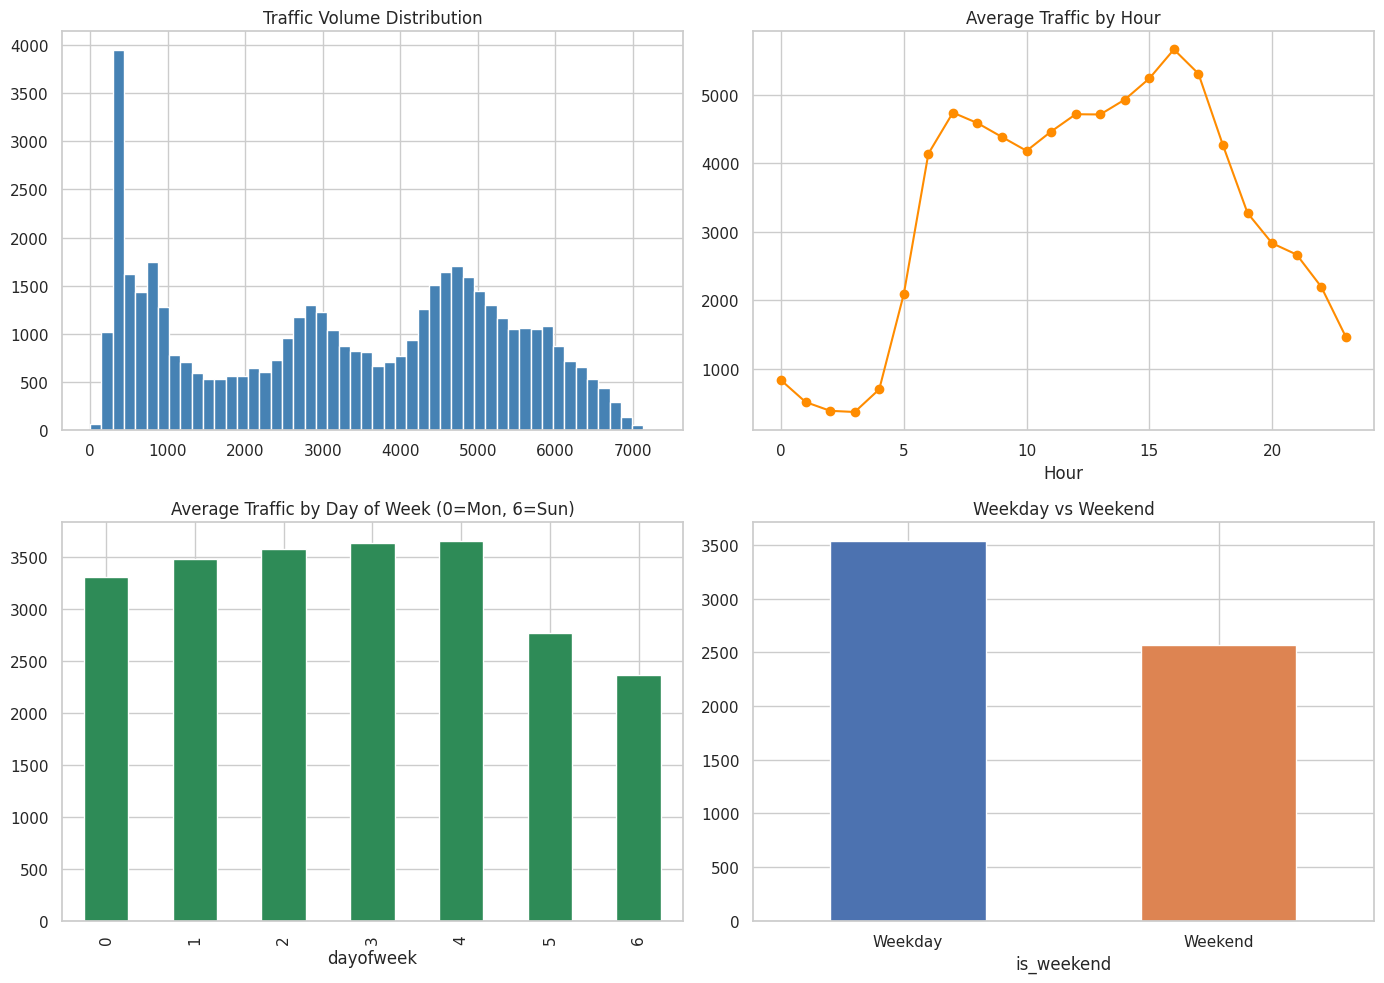

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Distribution
df_clean['traffic_volume'].hist(bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Traffic Volume Distribution')

# 2. Traffic by hour
df_clean.groupby('hour')['traffic_volume'].mean().plot(ax=axes[0,1], marker='o', color='darkorange')
axes[0,1].set_title('Average Traffic by Hour')
axes[0,1].set_xlabel('Hour')

# 3. Traffic by day of week
df_clean.groupby('dayofweek')['traffic_volume'].mean().plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Average Traffic by Day of Week (0=Mon, 6=Sun)')

# 4. Weekday vs Weekend
df_clean.groupby('is_weekend')['traffic_volume'].mean().plot(kind='bar', ax=axes[1,1], color=['#4c72b0','#dd8452'])
axes[1,1].set_xticklabels(['Weekday','Weekend'], rotation=0)
axes[1,1].set_title('Weekday vs Weekend')

plt.tight_layout()
plt.show()

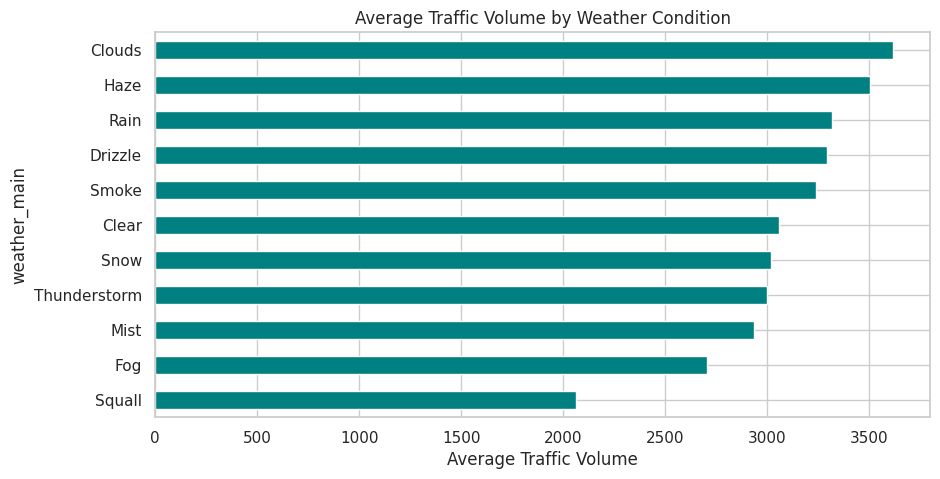

In [19]:
# Weather impact
plt.figure(figsize=(10,5))
df_clean.groupby('weather_main')['traffic_volume'].mean().sort_values().plot(kind='barh', color='teal')
plt.title('Average Traffic Volume by Weather Condition')
plt.xlabel('Average Traffic Volume')
plt.show()

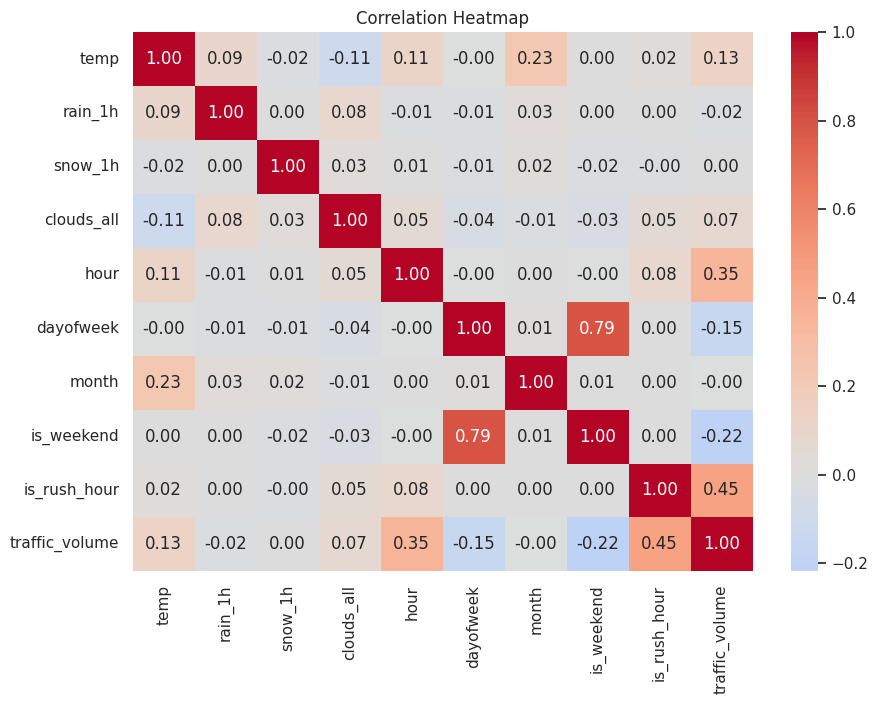

In [20]:
# Correlation heatmap
plt.figure(figsize=(10,7))
corr_cols = ['temp','rain_1h','snow_1h','clouds_all','hour','dayofweek','month',
             'is_weekend','is_rush_hour','traffic_volume']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 4. Feature Engineering

We perform **targeted feature expansion of meteorological data** combined with temporal features:
- **Meteorological**: temperature, rain, snow, cloud cover, one-hot encoded weather categories
- **Temporal**: hour, day of week, month, is_weekend, is_rush_hour

In [21]:
df_fe = df_clean.copy()

# One-hot encode weather_main
df_fe = pd.get_dummies(df_fe, columns=['weather_main'], prefix='weather_main')

# Drop columns we won't use
df_fe = df_fe.drop(columns=['holiday', 'date_time', 'weather_description'])

# Define feature groups
meteo_features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all'] + \
                 [c for c in df_fe.columns if c.startswith('weather_main_')]
temporal_features = ['hour', 'dayofweek', 'month', 'is_weekend', 'is_rush_hour']
all_features = meteo_features + temporal_features

X = df_fe[all_features].astype(float)
y_reg = df_fe['traffic_volume']

print('Total features      :', len(all_features))
print('Meteorological      :', len(meteo_features))
print('Temporal            :', len(temporal_features))
print('X shape             :', X.shape)
print('y (regression) shape:', y_reg.shape)

Total features      : 20
Meteorological      : 15
Temporal            : 5
X shape             : (48176, 20)
y (regression) shape: (48176,)


## 4.1 Create Classification Target

To enable classification evaluation, we bin `traffic_volume` into three categories using quantile-based binning: **Low**, **Medium**, **High**.

In [22]:
# Quantile-based binning for classification target
y_class = pd.qcut(y_reg, q=3, labels=['Low','Medium','High'])
print('Class distribution:')
print(y_class.value_counts())

# Label encode for sklearn/xgboost compatibility
le = LabelEncoder()
y_class_encoded = le.fit_transform(y_class)
print('\nEncoded labels:', dict(zip(le.classes_, le.transform(le.classes_))))

Class distribution:
traffic_volume
Medium    16060
Low       16059
High      16057
Name: count, dtype: int64

Encoded labels: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


# 5. Train/Test Split & Normalization

We use an 80/20 split and **Min-Max-style standardization via StandardScaler** for models that need it (Linear/Logistic Regression). Tree-based models use the unscaled features.

In [23]:
# Split (same split for regression and classification)
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_class_encoded, test_size=0.2, random_state=42, stratify=y_class_encoded
)

# Scaled version
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Train size: 38540
Test size : 9636


# 6. Evaluation Helper Functions

We compute **both** regression metrics (MAE, RMSE, R²) and classification-style metrics (Accuracy, Precision, Recall, F1) for regression models, by binning predictions into Low/Medium/High using the same quantile thresholds derived from the training target.

In [24]:
# Compute bin edges from training target so we can convert continuous predictions to classes
bin_edges = np.quantile(y_train_reg, [0, 1/3, 2/3, 1.0])
bin_edges[0]  -= 1e-6
bin_edges[-1] += 1e-6
print('Bin edges (Low | Medium | High):', bin_edges)

def to_class(values):
    """Bin continuous values into 0=Low, 1=Medium, 2=High using training quantiles."""
    return np.clip(np.digitize(values, bin_edges[1:-1]), 0, 2)

def evaluate_regression(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)

    # Derived classification metrics
    yt_cls = to_class(y_true)
    yp_cls = to_class(y_pred)
    acc  = accuracy_score(yt_cls, yp_cls)
    prec = precision_score(yt_cls, yp_cls, average='macro', zero_division=0)
    rec  = recall_score(yt_cls, yp_cls, average='macro', zero_division=0)
    f1   = f1_score(yt_cls, yp_cls, average='macro', zero_division=0)

    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

def evaluate_classification(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

print('Helper functions ready.')

Bin edges (Low | Medium | High): [-1.00000000e-06  2.19533333e+03  4.57100000e+03  7.28000000e+03]
Helper functions ready.


# 7. Regression Models

We train 5 supervised regression algorithms:
1. **Linear Regression** — baseline
2. **Decision Tree Regressor**
3. **Random Forest Regressor**
4. **XGBoost Regressor**
5. **CatBoost Regressor**

In [25]:
reg_results = []

# 1. Linear Regression (uses scaled features)
print('Training Linear Regression...')
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_reg)
pred = lr.predict(X_test_scaled)
reg_results.append(evaluate_regression('Linear Regression', y_test_reg, pred))

# 2. Decision Tree
print('Training Decision Tree Regressor...')
dt_reg = DecisionTreeRegressor(max_depth=15, random_state=42)
dt_reg.fit(X_train, y_train_reg)
pred = dt_reg.predict(X_test)
reg_results.append(evaluate_regression('Decision Tree', y_test_reg, pred))

# 3. Random Forest
print('Training Random Forest Regressor...')
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_reg.fit(X_train, y_train_reg)
pred = rf_reg.predict(X_test)
reg_results.append(evaluate_regression('Random Forest', y_test_reg, pred))

# 4. XGBoost
print('Training XGBoost Regressor...')
xgb_reg = XGBRegressor(n_estimators=400, max_depth=8, learning_rate=0.1,
                      random_state=42, n_jobs=-1, verbosity=0)
xgb_reg.fit(X_train, y_train_reg)
pred = xgb_reg.predict(X_test)
reg_results.append(evaluate_regression('XGBoost', y_test_reg, pred))

# 5. CatBoost
print('Training CatBoost Regressor...')
cb_reg = CatBoostRegressor(iterations=500, depth=8, learning_rate=0.1,
                          loss_function='RMSE', verbose=0, random_state=42)
cb_reg.fit(X_train, y_train_reg)
pred = cb_reg.predict(X_test)
reg_results.append(evaluate_regression('CatBoost', y_test_reg, pred))

reg_df = pd.DataFrame(reg_results)
print('\n=== REGRESSION RESULTS ===')
reg_df.round(4)

Training Linear Regression...
Training Decision Tree Regressor...
Training Random Forest Regressor...
Training XGBoost Regressor...
Training CatBoost Regressor...

=== REGRESSION RESULTS ===


,Model,MAE,RMSE,R2,Accuracy,Precision,Recall,F1
0,Linear Regression,1356.8458,1571.9854,0.3765,0.5523,0.6665,0.5523,0.5513
1,Decision Tree,286.3236,537.8274,0.9270,0.8825,0.8823,0.8825,0.8823
2,Random Forest,253.3284,449.9420,0.9489,0.8956,0.8966,0.8956,0.8960
3,XGBoost,235.5937,404.4999,0.9587,0.9016,0.9023,0.9016,0.9019
4,CatBoost,248.6354,420.7674,0.9553,0.8976,0.8985,0.8976,0.8979


# 8. Classification Models

We train 4 supervised classification algorithms on the binned target (Low/Medium/High):
1. **Logistic Regression**
2. **Decision Tree Classifier**
3. **Random Forest Classifier**
4. **XGBoost Classifier**

In [26]:
clf_results = []

# 1. Logistic Regression
print('Training Logistic Regression...')
lr_clf = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)
lr_clf.fit(X_train_scaled, y_train_clf)
pred = lr_clf.predict(X_test_scaled)
clf_results.append(evaluate_classification('Logistic Regression', y_test_clf, pred))

# 2. Decision Tree
print('Training Decision Tree Classifier...')
dt_clf = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_clf.fit(X_train, y_train_clf)
pred = dt_clf.predict(X_test)
clf_results.append(evaluate_classification('Decision Tree', y_test_clf, pred))

# 3. Random Forest
print('Training Random Forest Classifier...')
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_clf.fit(X_train, y_train_clf)
pred = rf_clf.predict(X_test)
clf_results.append(evaluate_classification('Random Forest', y_test_clf, pred))

# 4. XGBoost
print('Training XGBoost Classifier...')
xgb_clf = XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.1,
                       random_state=42, n_jobs=-1, verbosity=0,
                       use_label_encoder=False, eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train_clf)
pred = xgb_clf.predict(X_test)
clf_results.append(evaluate_classification('XGBoost', y_test_clf, pred))

clf_df = pd.DataFrame(clf_results)
print('\n=== CLASSIFICATION RESULTS ===')
clf_df.round(4)

Training Logistic Regression...
Training Decision Tree Classifier...
Training Random Forest Classifier...
Training XGBoost Classifier...

=== CLASSIFICATION RESULTS ===


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.6749,0.6834,0.6749,0.6770
1,Decision Tree,0.8893,0.8891,0.8893,0.8890
2,Random Forest,0.8982,0.8988,0.8982,0.8983
3,XGBoost,0.9123,0.9124,0.9123,0.9122


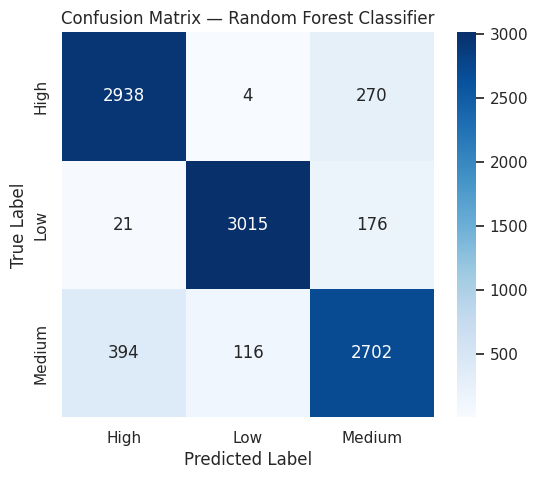


Classification Report — Random Forest:
              precision    recall  f1-score   support

        High       0.88      0.91      0.90      3212
         Low       0.96      0.94      0.95      3212
      Medium       0.86      0.84      0.85      3212

    accuracy                           0.90      9636
   macro avg       0.90      0.90      0.90      9636
weighted avg       0.90      0.90      0.90      9636



In [27]:
# Confusion matrix for best classifier (Random Forest)
from sklearn.metrics import ConfusionMatrixDisplay

best_pred = rf_clf.predict(X_test)
cm = confusion_matrix(y_test_clf, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Random Forest Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print('\nClassification Report — Random Forest:')
print(classification_report(y_test_clf, best_pred, target_names=le.classes_))

# 9. Clustering — K-Means

We apply **unsupervised learning** to discover natural traffic patterns. K-Means clustering groups observations based on meteorological + temporal features, allowing us to identify recurring traffic conditions.

We evaluate using the **Silhouette Score** (range -1 to 1; higher is better).

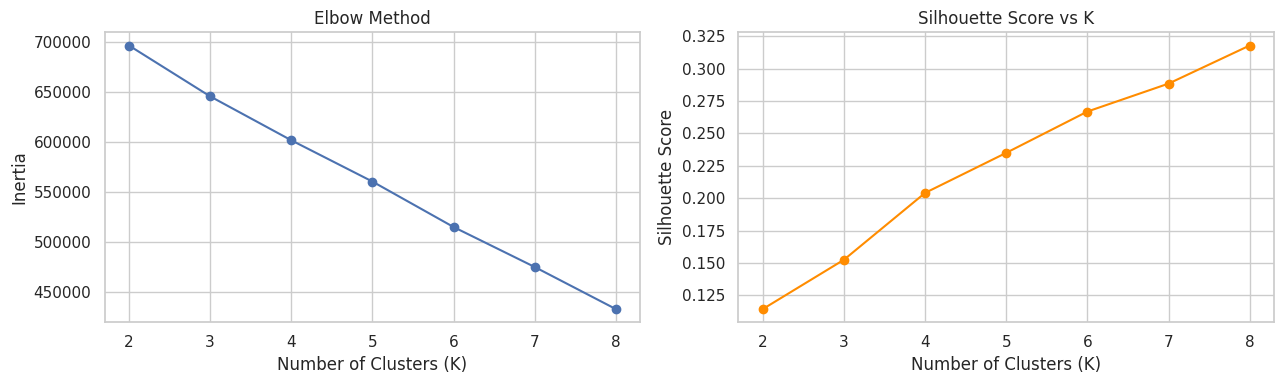

Silhouette scores: {2: np.float64(0.1143), 3: np.float64(0.1524), 4: np.float64(0.2041), 5: np.float64(0.235), 6: np.float64(0.2669), 7: np.float64(0.2885), 8: np.float64(0.318)}


In [28]:
# Elbow method to choose K
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

print('Silhouette scores:', dict(zip(K_range, [round(s,4) for s in sil_scores])))

In [29]:
# Fit K-Means with chosen K (use K with best silhouette)
best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f'Best K = {best_k}')

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_scaled)
final_sil = silhouette_score(X_train_scaled, cluster_labels, sample_size=5000, random_state=42)
print(f'Final Silhouette Score: {final_sil:.4f}')

# Mean traffic per cluster — interprets what each cluster represents
cluster_summary = pd.DataFrame({
    'cluster': cluster_labels,
    'traffic_volume': y_train_reg.values,
    'hour': X_train['hour'].values,
    'is_weekend': X_train['is_weekend'].values,
    'temp': X_train['temp'].values
})

print('\nCluster characteristics:')
print(cluster_summary.groupby('cluster').agg({
    'traffic_volume': 'mean',
    'hour': 'mean',
    'is_weekend': 'mean',
    'temp': 'mean'
}).round(2))

Best K = 8
Final Silhouette Score: 0.3180

Cluster characteristics:
         traffic_volume   hour  is_weekend    temp
cluster                                           
0               3289.75  11.45        0.26  283.84
1               3007.80  11.05        0.25  267.92
2               2942.54   9.51        0.28  279.44
3               3312.68  11.64        0.26  286.99
4               3556.91  12.17        0.28  281.32
5               3541.10  11.57        0.27  275.64
6               3060.66  11.23        0.31  281.71
7               3020.03  11.18        0.31  292.68


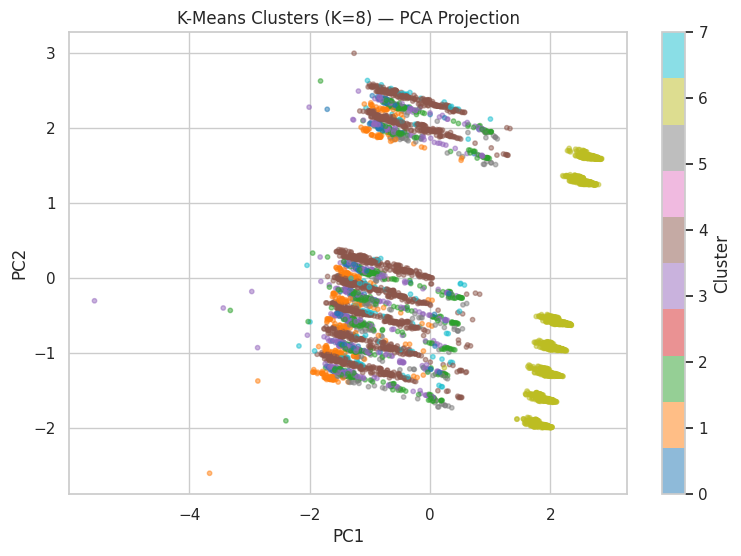

In [30]:
# Visualize clusters in 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

# Sample for plotting speed
sample_idx = np.random.choice(len(X_pca), size=min(5000, len(X_pca)), replace=False)

plt.figure(figsize=(9,6))
scatter = plt.scatter(X_pca[sample_idx,0], X_pca[sample_idx,1],
                     c=cluster_labels[sample_idx], cmap='tab10', alpha=0.5, s=10)
plt.title(f'K-Means Clusters (K={best_k}) — PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.show()

# 10. Test Scenarios

## Scenario 1 — Method Comparison

Compare all regression and classification models side by side.

In [31]:
print('=== REGRESSION MODELS ===')
print(reg_df.round(4).to_string(index=False))
print('\n=== CLASSIFICATION MODELS ===')
print(clf_df.round(4).to_string(index=False))

=== REGRESSION MODELS ===
            Model       MAE      RMSE     R2  Accuracy  Precision  Recall     F1
Linear Regression 1356.8458 1571.9854 0.3765    0.5523     0.6665  0.5523 0.5513
    Decision Tree  286.3236  537.8274 0.9270    0.8825     0.8823  0.8825 0.8823
    Random Forest  253.3284  449.9420 0.9489    0.8956     0.8966  0.8956 0.8960
          XGBoost  235.5937  404.4999 0.9587    0.9016     0.9023  0.9016 0.9019
         CatBoost  248.6354  420.7674 0.9553    0.8976     0.8985  0.8976 0.8979

=== CLASSIFICATION MODELS ===
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.6749     0.6834  0.6749 0.6770
      Decision Tree    0.8893     0.8891  0.8893 0.8890
      Random Forest    0.8982     0.8988  0.8982 0.8983
            XGBoost    0.9123     0.9124  0.9123 0.9122


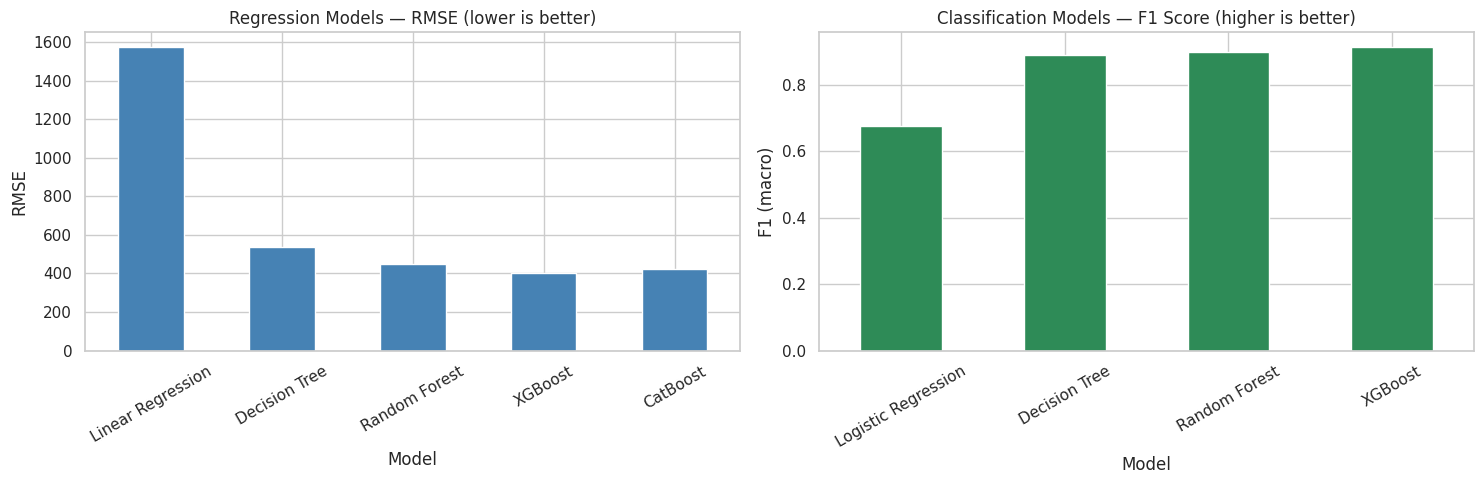

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Regression: RMSE
reg_df.set_index('Model')['RMSE'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Regression Models — RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)

# Classification: F1
clf_df.set_index('Model')['F1'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Classification Models — F1 Score (higher is better)')
axes[1].set_ylabel('F1 (macro)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

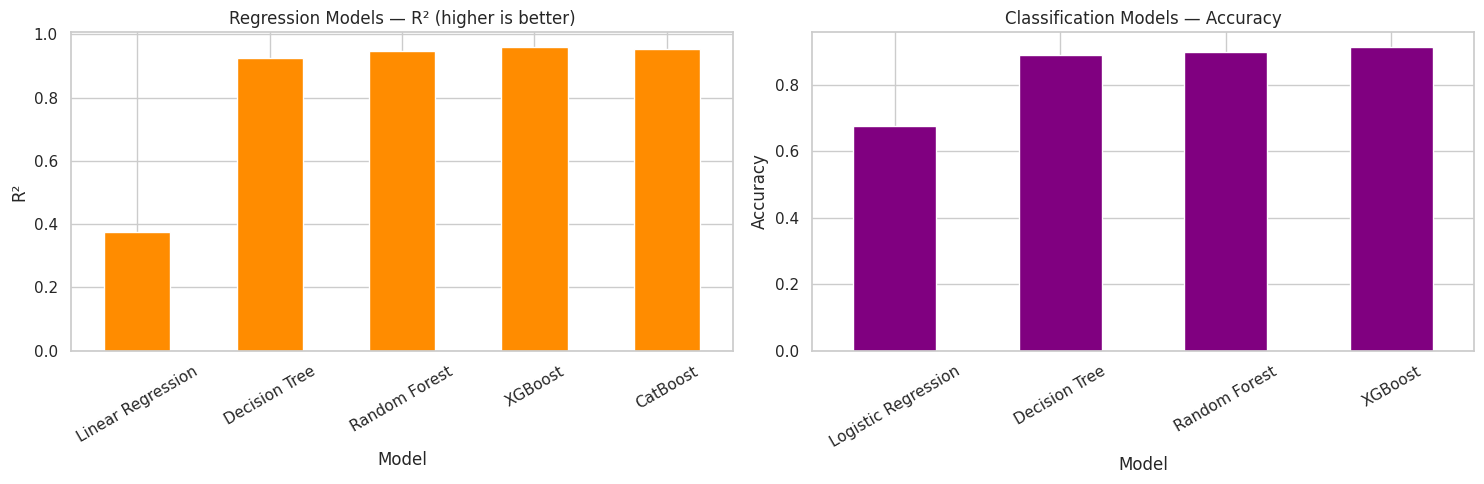

In [33]:
# Regression R² comparison
fig, axes = plt.subplots(1, 2, figsize=(15,5))

reg_df.set_index('Model')['R2'].plot(kind='bar', ax=axes[0], color='darkorange')
axes[0].set_title('Regression Models — R² (higher is better)')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0, color='black', linewidth=0.5)

clf_df.set_index('Model')['Accuracy'].plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title('Classification Models — Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Scenario 2 — Feature Ablation Study

This scenario directly tests the core hypothesis of MetTraff: **targeted feature expansion of meteorological data improves prediction**. We train the best regressor (CatBoost) under three feature configurations:
1. **Meteorological only** — weather-related features
2. **Temporal only** — time-related features
3. **Combined** — all features

In [34]:
def train_eval_subset(feature_list, label):
    Xtr = X_train[feature_list]
    Xte = X_test[feature_list]
    m = CatBoostRegressor(iterations=400, depth=8, learning_rate=0.1, verbose=0, random_state=42)
    m.fit(Xtr, y_train_reg)
    pred = m.predict(Xte)
    return evaluate_regression(label, y_test_reg, pred)

ablation = [
    train_eval_subset(meteo_features,    'Meteorological only'),
    train_eval_subset(temporal_features, 'Temporal only'),
    train_eval_subset(all_features,      'Combined (MetTraff)')
]
ablation_df = pd.DataFrame(ablation)
print('=== FEATURE ABLATION RESULTS ===')
ablation_df.round(4)

=== FEATURE ABLATION RESULTS ===


,Model,MAE,RMSE,R2,Accuracy,Precision,Recall,F1
0,Meteorological only,1616.6562,1879.5852,0.1086,0.3554,0.5263,0.3554,0.2406
1,Temporal only,274.6717,478.2788,0.9423,0.8878,0.8890,0.8878,0.8883
2,Combined (MetTraff),250.7904,424.4419,0.9545,0.8985,0.8994,0.8985,0.8989


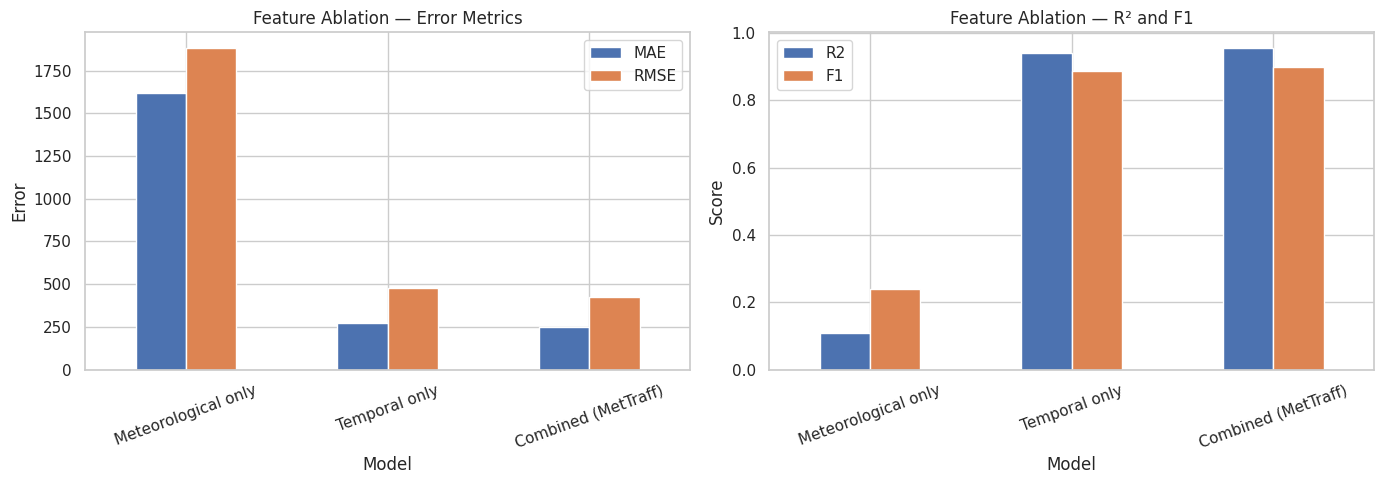

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

ablation_df.set_index('Model')[['MAE','RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Feature Ablation — Error Metrics')
axes[0].set_ylabel('Error')
axes[0].tick_params(axis='x', rotation=20)

ablation_df.set_index('Model')[['R2','F1']].plot(kind='bar', ax=axes[1], color=['#4c72b0','#dd8452'])
axes[1].set_title('Feature Ablation — R² and F1')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Scenario 3 — Hyperparameter Tuning (Optuna)

We tune CatBoost using **Optuna** (Bayesian optimization, 20 trials) and compare against the default-parameter CatBoost from Scenario 1.

In [36]:
def objective(trial):
    params = {
        'iterations'        : trial.suggest_int('iterations', 300, 1000),
        'depth'             : trial.suggest_int('depth', 4, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength'   : trial.suggest_float('random_strength', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'border_count'      : trial.suggest_int('border_count', 32, 255),
        'loss_function'     : 'RMSE',
        'verbose'           : 0,
        'random_state'      : 42
    }
    m = CatBoostRegressor(**params)
    m.fit(X_train, y_train_reg)
    pred = m.predict(X_test)
    return mean_squared_error(y_test_reg, pred) ** 0.5

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print('Best params:', study.best_params)
print('Best RMSE  :', round(study.best_value, 4))

Best params: {'iterations': 929, 'depth': 9, 'learning_rate': 0.2980401574578896, 'l2_leaf_reg': 7.472567033051656, 'random_strength': 7.835338748202453, 'bagging_temperature': 0.4157677078071893, 'border_count': 87}
Best RMSE  : 397.151


In [37]:
# Train tuned CatBoost with best params
best_params = study.best_params
cb_tuned = CatBoostRegressor(**best_params, loss_function='RMSE', verbose=0, random_state=42)
cb_tuned.fit(X_train, y_train_reg)
pred_tuned = cb_tuned.predict(X_test)

tuning_results = [
    evaluate_regression('CatBoost — Default', y_test_reg, cb_reg.predict(X_test)),
    evaluate_regression('CatBoost — Tuned (Optuna)', y_test_reg, pred_tuned)
]
tuning_df = pd.DataFrame(tuning_results)
print('=== HYPERPARAMETER TUNING ===')
tuning_df.round(4)

=== HYPERPARAMETER TUNING ===


,Model,MAE,RMSE,R2,Accuracy,Precision,Recall,F1
0,CatBoost — Default,248.6354,420.7674,0.9553,0.8976,0.8985,0.8976,0.8979
1,CatBoost — Tuned (Optuna),239.4414,397.1510,0.9602,0.9034,0.9044,0.9034,0.9038


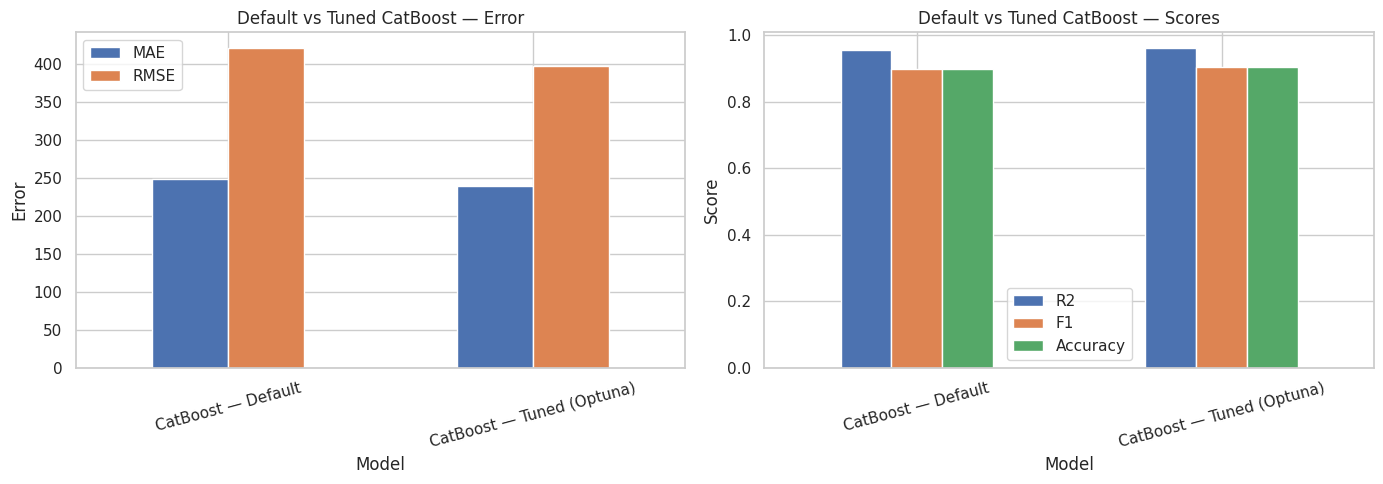

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

tuning_df.set_index('Model')[['MAE','RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Default vs Tuned CatBoost — Error')
axes[0].set_ylabel('Error')
axes[0].tick_params(axis='x', rotation=15)

tuning_df.set_index('Model')[['R2','F1','Accuracy']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Default vs Tuned CatBoost — Scores')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# 11. Feature Importance

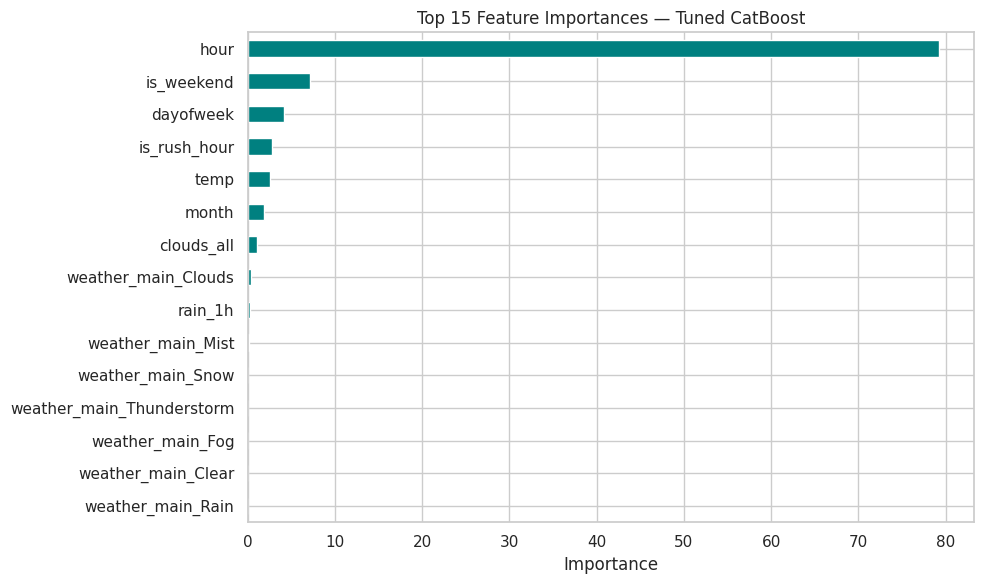

hour                         79.2897
is_weekend                    7.1199
dayofweek                     4.1768
is_rush_hour                  2.8255
temp                          2.5504
month                         1.9245
clouds_all                    1.0673
weather_main_Clouds           0.3470
rain_1h                       0.2214
weather_main_Mist             0.1037
weather_main_Snow             0.0814
weather_main_Thunderstorm     0.0774
weather_main_Fog              0.0740
weather_main_Clear            0.0389
weather_main_Rain             0.0343
dtype: float64


In [39]:
importance = pd.Series(cb_tuned.get_feature_importance(), index=X.columns)
top = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top.sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances — Tuned CatBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(top.round(4))

# 12. Save Final Model

In [40]:
joblib.dump(cb_tuned, 'traffic_model.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_order.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
print('Model and artifacts saved.')

Model and artifacts saved.


In [41]:
# Example prediction
sample = pd.DataFrame([{
    'temp': 285, 'rain_1h': 0, 'snow_1h': 0, 'clouds_all': 80,
    'hour': 8, 'dayofweek': 1, 'month': 10,
    'is_weekend': 0, 'is_rush_hour': 1
}])
# Fill missing one-hot columns
for col in X.columns:
    if col not in sample.columns:
        sample[col] = 0
sample = sample[X.columns]

pred_volume = cb_tuned.predict(sample)[0]
pred_class  = ['Low','Medium','High'][int(to_class(np.array([pred_volume]))[0])]
print(f'Predicted traffic volume: {pred_volume:.0f} vehicles/hour')
print(f'Predicted category     : {pred_class}')

Predicted traffic volume: 5747 vehicles/hour
Predicted category     : High


# 13. Summary of Results

| Scenario | Best Model | Key Metric |
|---------|-----------|-----------|
| Method Comparison (Regression) | See `reg_df` | Lowest RMSE / highest R² |
| Method Comparison (Classification) | See `clf_df` | Highest F1 / Accuracy |
| Feature Ablation | Combined (MetTraff) | Demonstrates value of fused features |
| Hyperparameter Tuning | Tuned CatBoost | Improvement over default |
| Clustering (K-Means) | K = (best from elbow) | Silhouette score |

**Conclusion**: The MetTraff approach — combining targeted meteorological feature expansion with temporal features — outperforms either feature group alone, and tree-based gradient boosting (CatBoost/XGBoost) consistently outperforms simpler baselines across both regression and classification framings.